# Spatially Explicit Dataset Example

We had to patch the `libcbm` code to get it to run correctly with a "spatially explicit" SIT input dataset (which we exported from a spatially explicit Patchworks model of the UBC Malcolm Knapp Research Forest using the _Export to CBM-CFS3_ tool).

See [this PDF document](https://carbon.nfis.org/cbm/downloadFile.action?file_id=1745) for details of "spatially explicit" (technically "spatially referenced" is a more accurate term for what is really happening here) modelling in CBM-CFS3 (requires NFIS login to access, concept maps well to `libcbm` which has the same structure as CBM-CFS3). The main `libcbm` developer (Scott Morken) confirmed that `libcbm` code was developed with the intent of accepting spatially explicit but that this path through the code was not throughly tested end-to-end with a full-sized dataset. Our patched code seems to run well, but testing is still in progress.

Our patched fork of `libcbm`is available here:

https://github.com/gparadis/libcbm_py

The patched fork will eventually be merged with the official distribution here:

https://github.com/cat-cfs/libcbm_py

We have added our "spatially explicit" test dataset (under `libcbm/resources/test/sit_spatially_explicit`) and this notebook (under `examples/sit_spatially_explicit`) to our patched fork.

Import required packages and modules.


In [1]:
import os, json
import pandas as pd
%matplotlib inline

In [7]:
from libcbm.input.sit import sit_cbm_factory
from libcbm.model.cbm import cbm_simulator
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm import resources

## Setup
Load the standard import tool configuration at the specified path.  This configuration encompasses the data source for the various sit inputs (sit_inventory, sit_classifiers etc.) and also the relationships of classifiers, and disturbance types to the default CBM parameters.


In [8]:
config_path = os.path.join(resources.get_test_resources_dir(),
                           "sit_spatially_explicit",
                           "sit_config.json")
sit = sit_cbm_factory.load_sit(config_path)

Initialize and validate the inventory in the SIT dataset.


In [9]:
classifiers, inventory = sit_cbm_factory.initialize_inventory(sit)

Create storage and a function for storing CBM simulation results.  This particular implementation appends timestep results for each step into a running DataFrame which is stored in memory.


In [10]:
cbm_output = CBMOutput(
    classifier_map=sit.classifier_value_names,
    disturbance_type_map=sit.disturbance_name_map)

## Simulation

At this point the environment is ready to simulate growth and disturbance in each of our spatially referenced stands for a user-defined number of one-year discrete time steps (200 in the example below).


In [11]:
with sit_cbm_factory.initialize_cbm(sit) as cbm:
    # Apply rule based disturbance events and transition rules based on the SIT input
    rule_based_processor = sit_cbm_factory.create_sit_rule_based_processor(sit, cbm)

    def pre_dynamics_func(t, cbm_vars):
        print(t)
        return rule_based_processor.pre_dynamics_func(t, cbm_vars)
    # The following line of code spins up the CBM inventory and runs it through 200 timesteps.
    cbm_simulator.simulate(
        cbm,
        n_steps              = 200,
        classifiers          = classifiers,
        inventory            = inventory,
        pre_dynamics_func    = pre_dynamics_func,
        reporting_func       = cbm_output.append_simulation_result,
    )

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200


Dump table of classifier values.


In [12]:
cbm_output.classifiers.to_pandas()

,identifier,timestep,Track,State,au,LeadSpecies
0,1,0,1,managed,2121,softwood
1,2,0,3,managed,2104,softwood
2,3,0,3,managed,2104,softwood
3,4,0,5,managed,2113,softwood
4,5,0,5,managed,2113,softwood
...,...,...,...,...,...,...
285415,1416,200,8,managed,2022,softwood
285416,1417,200,8,managed,2022,softwood
285417,1418,200,4,managed,2004,softwood
285418,1419,200,12,managed,2023,softwood


## Results

### Pool Stocks


In [13]:
pi = cbm_output.classifiers.to_pandas().merge(cbm_output.pools.to_pandas(), left_on=["identifier", "timestep"], right_on=["identifier", "timestep"])

In [14]:
pi.head()

,identifier,timestep,Track,State,au,LeadSpecies,Input,SoftwoodMerch,SoftwoodFoliage,SoftwoodOther,...,BelowGroundSlowSoil,SoftwoodStemSnag,SoftwoodBranchSnag,HardwoodStemSnag,HardwoodBranchSnag,CO2,CH4,CO,NO2,Products
0,1,0,1,managed,2121,softwood,2.045750,151.416222,21.578364,82.055402,...,420.769253,11.511631,5.107295,0.0,0.0,55383.856356,17.667886,159.015723,0.0,346.803167
1,2,0,3,managed,2104,softwood,7.437000,7.808557,26.382624,13.496410,...,2393.902879,0.074194,0.117392,0.0,0.0,296501.104750,83.850936,754.682807,0.0,1966.618771
2,3,0,3,managed,2104,softwood,0.118866,0.124805,0.421675,0.215714,...,38.261888,0.001186,0.001876,0.0,0.0,4738.994261,1.340194,12.062139,0.0,31.432581
3,4,0,5,managed,2113,softwood,7.194100,3.400270,25.130360,0.894679,...,2266.937495,0.034053,0.004243,0.0,0.0,279331.838073,83.452469,751.096213,0.0,2047.958936
4,5,0,5,managed,2113,softwood,4.298460,3.051019,16.765435,3.701929,...,1355.137148,0.034475,0.022256,0.0,0.0,166961.314194,49.862679,448.778447,0.0,1223.651266


<Axes: xlabel='Year'>

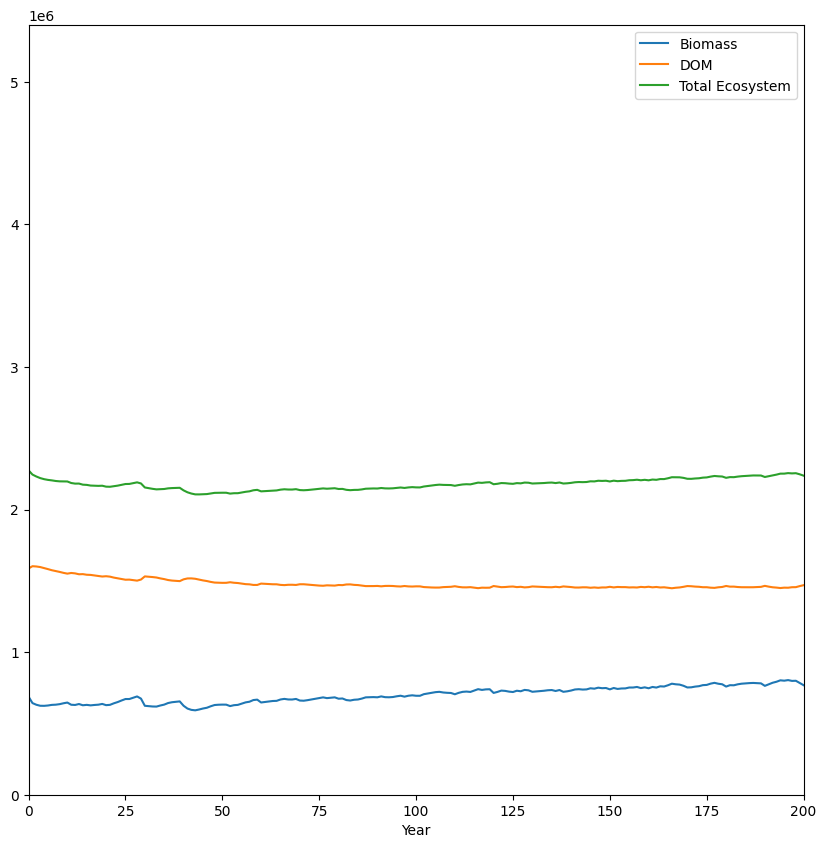

In [15]:
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots', 'SoftwoodFineRoots',
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']

dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']

biomass_result = pi[['timestep']+biomass_pools]
dom_result = pi[['timestep']+dom_pools]
total_eco_result = pi[['timestep']+biomass_pools+dom_pools]

annual_carbon_stocks = pd.DataFrame(
    {
        "Year": pi["timestep"],
        "Biomass": pi[biomass_pools].sum(axis=1),
        "DOM": pi[dom_pools].sum(axis=1),
        "Total Ecosystem": pi[biomass_pools+dom_pools].sum(axis=1)})

annual_carbon_stocks.groupby("Year").sum().plot(figsize=(10,10),xlim=(0,200),ylim=(0,5.4e6))


### State Variables


In [16]:
si = cbm_output.state.to_pandas()
si.head()

,identifier,timestep,last_disturbance_type,last_disturbance_event,time_since_last_disturbance,time_since_land_class_change,growth_enabled,enabled,land_class,age,growth_multiplier,regeneration_delay
0,1,0,CC,0,69,69,1,1,0,69,1.0,0
1,2,0,CC,0,6,6,1,1,0,6,1.0,0
2,3,0,CC,0,6,6,1,1,0,6,1.0,0
3,4,0,CC,0,7,7,1,1,0,7,1.0,0
4,5,0,CC,0,8,8,1,1,0,8,1.0,0


<Axes: xlabel='timestep'>

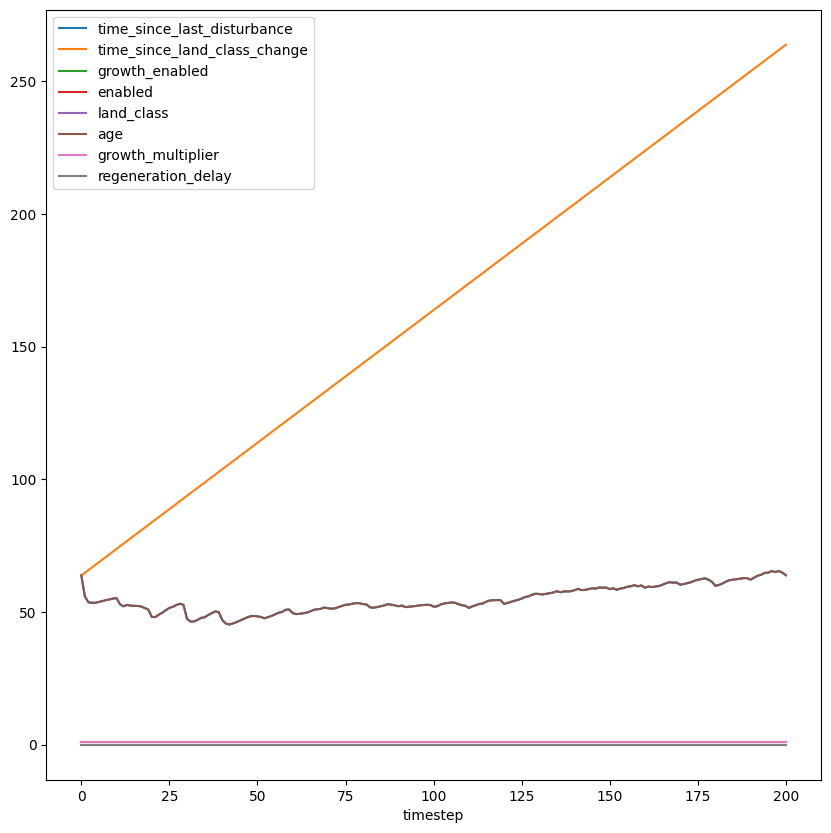

In [17]:
state_variables = ['timestep', 'time_since_last_disturbance', 'time_since_land_class_change',
 'growth_enabled', 'enabled', 'land_class', 'age', 'growth_multiplier', 'regeneration_delay']
si[state_variables].groupby('timestep').mean().plot(figsize=(10,10))

### Pool Fluxes


In [18]:
fi = cbm_output.flux.to_pandas()
fi.head()

,identifier,timestep,DisturbanceCO2Production,DisturbanceCH4Production,DisturbanceCOProduction,DisturbanceBioCO2Emission,DisturbanceBioCH4Emission,DisturbanceBioCOEmission,DecayDOMCO2Emission,DisturbanceSoftProduction,...,DisturbanceVFastBGToAir,DisturbanceFastAGToAir,DisturbanceFastBGToAir,DisturbanceMediumToAir,DisturbanceSlowAGToAir,DisturbanceSlowBGToAir,DisturbanceSWStemSnagToAir,DisturbanceSWBranchSnagToAir,DisturbanceHWStemSnagToAir,DisturbanceHWBranchSnagToAir
0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
annual_process_fluxes = [
    'DecayDOMCO2Emission',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']

<Axes: xlabel='timestep'>

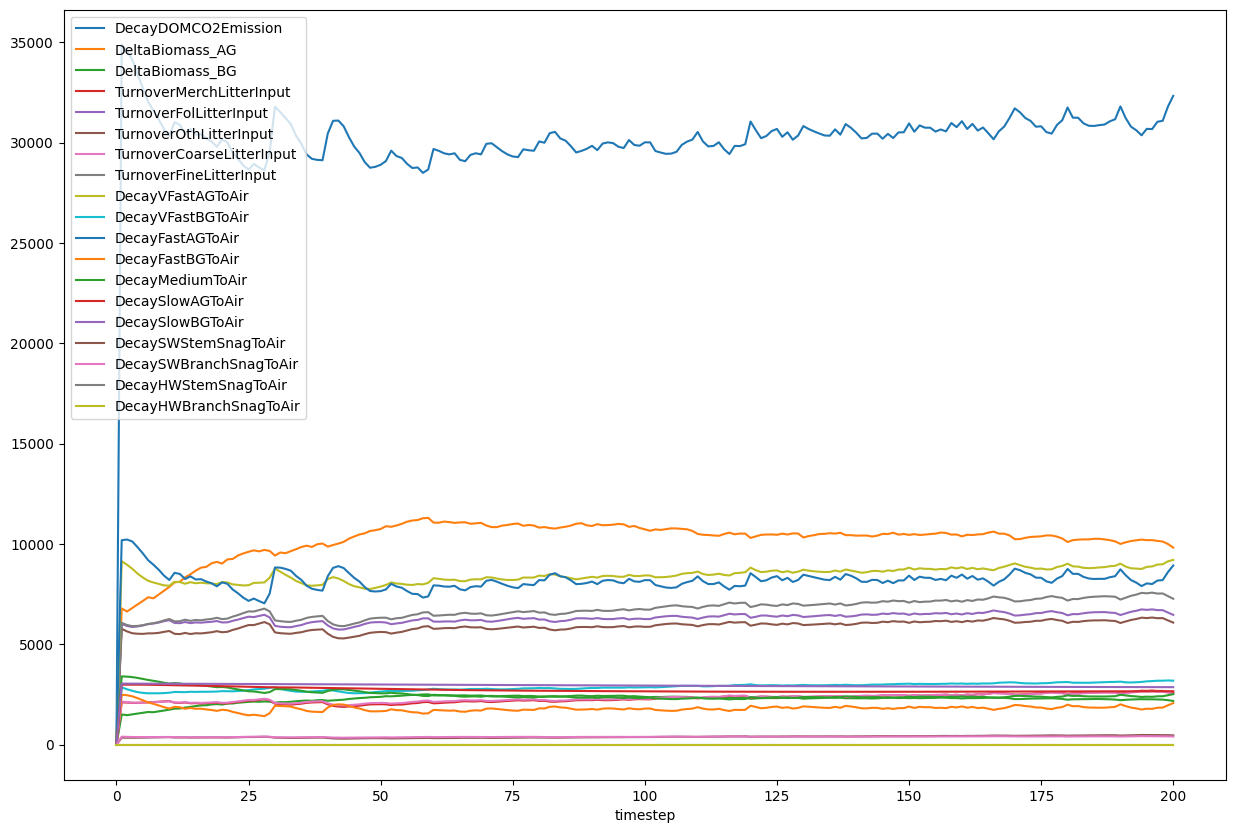

In [20]:
fi[["timestep"]+annual_process_fluxes].groupby("timestep").sum().plot(figsize=(15,10))

### Disturbance Statistics

The following call returns `None`. This is expected, as the (patched) code for the spatially explicit case currently does not compile any disturbance statistics when a `RuleTargetResult` object instance is instantiated with the `spatially_indexed_target` function (i.e., the `statistics` attribute is explicitly set to `None`).


In [21]:
rule_based_processor.sit_event_stats_by_timestep[1]

In [22]:
rule_based_processor.sit_events

,Track,State,au,LeadSpecies,min_age,max_age,MinYearsSinceDist,MaxYearsSinceDist,LastDistTypeID,MinTotBiomassC,...,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,time_step,spatial_reference,disturbance_type_id,sort_field
0,1,managed,2121,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC,30,14,1,1
1,2,managed,2021,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC$1,95,14,2,2
2,2,managed,2021,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC$1,178,14,2,2
3,2,managed,2021,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC$1,260,14,2,2
4,3,managed,2104,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC,60,15,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633,430,managed,451,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC,162,1868,1,1
4634,136,managed,2102,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC,40,1869,1,1
4635,100,managed,2002,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC$1,116,1869,2,2
4636,100,managed,2002,softwood,1,999,-1.0,-1.0,-1,-1.0,...,-1.0,1.0,SVOID,Proportion,1.0,CC$1,188,1869,2,2


## Appendix

### SIT source data


In [23]:
sit.sit_data.age_classes

,name,class_size,start_year,end_year
0,AGEID0,0,0,0
1,AGEID1,5,1,5
2,AGEID2,5,6,10
3,AGEID3,5,11,15
4,AGEID4,5,16,20
...,...,...,...,...
196,AGEID196,5,976,980
197,AGEID197,5,981,985
198,AGEID198,5,986,990
199,AGEID199,5,991,995


In [24]:
sit.sit_data.inventory

,Track,State,au,LeadSpecies,age,area,delay,land_class,historical_disturbance_type,last_pass_disturbance_type,spatial_reference
0,1,managed,2121,softwood,69,2.045750,0,0,Fire,CC,14
1,3,managed,2104,softwood,6,7.437000,0,0,Fire,CC,15
2,3,managed,2104,softwood,6,0.118866,0,0,Fire,CC,16
3,5,managed,2113,softwood,7,7.194100,0,0,Fire,CC,19
4,5,managed,2113,softwood,8,4.298460,0,0,Fire,CC,20
...,...,...,...,...,...,...,...,...,...,...,...
1415,108,managed,520,softwood,102,6.028800,0,0,Fire,CC,1865
1416,7,managed,2122,softwood,49,5.760800,0,0,Fire,CC,1866
1417,3,managed,2104,softwood,69,2.157650,0,0,Fire,CC,1867
1418,430,managed,451,softwood,114,6.472200,0,0,Fire,CC,1868


In [25]:
sit.sit_data.classifiers

,id,name
0,1,Track
1,2,State
2,3,au
3,4,LeadSpecies


In [26]:
sit.sit_data.classifier_values

,classifier_id,name,description
4,1,1,1
5,1,2,2
6,1,3,3
7,1,4,4
8,1,5,5
...,...,...,...
859,3,2122,2122
860,3,2123,2123
861,3,2124,2124
862,3,2204,2204


In [27]:
sit.sit_data.disturbance_types

,sit_disturbance_type_id,id,name
0,1,CC,CC
1,2,CC$1,CC$1
2,3,Fire,Fire


In [28]:
sit.sit_data.yield_table

,Track,State,au,LeadSpecies,leading_species,v0,v1,v2,v3,v4,...,v191,v192,v193,v194,v195,v196,v197,v198,v199,v200
0,1,?,?,softwood,softwood,0.0,0.0,0.0,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,?,?,softwood,softwood,0.0,0.0,0.0,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,?,?,softwood,softwood,0.0,3.5,7.0,54.5000,102.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,?,?,softwood,softwood,0.0,3.5,7.0,53.5000,100.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,?,?,softwood,softwood,0.0,0.0,0.0,9.5000,19.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,426,?,?,softwood,softwood,0.0,0.0,0.0,6.8722,13.7444,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
426,427,?,?,softwood,softwood,0.0,0.0,0.0,14.2103,28.4206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
427,428,?,?,softwood,softwood,0.0,0.0,0.0,21.1038,42.2076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
428,429,?,?,softwood,softwood,0.0,0.0,0.0,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
print(json.dumps(sit.config, indent=4, sort_keys=True))

{
    "import_config": {
        "age_classes": {
            "params": {
                "path": "AgeClasses.csv"
            },
            "type": "csv"
        },
        "classifiers": {
            "params": {
                "path": "Classifiers.csv"
            },
            "type": "csv"
        },
        "disturbance_types": {
            "params": {
                "path": "DistType.csv"
            },
            "type": "csv"
        },
        "events": {
            "params": {
                "path": "DistEvents.csv"
            },
            "type": "csv"
        },
        "inventory": {
            "params": {
                "path": "Inventory.csv"
            },
            "type": "csv"
        },
        "transitions": {
            "params": {
                "path": "Transitions.csv"
            },
            "type": "csv"
        },
        "yield": {
            "params": {
                "path": "Growth.csv"
            },
            "type": "csv"
    